<h2 style = "text-align:center;">
Healthcare Exploratory Data Analysis
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\IDE\Projects\hospital-Operations-Analytics\Data\cleaned_patient_data.csv")

<h3 style = "text-align:left; text-decoration: underline;">
Basic Dataset Information
</h3>

In [3]:
df.head()

,patient_id,patient_admission_date,patient_admission_time,patient_name,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [4]:
print("Dataset Shape")
df.shape

Dataset Shape


(9216, 11)

In [5]:
print("Column Names")
df.columns

Column Names


Index(['patient_id', 'patient_admission_date', 'patient_admission_time',
       'patient_name', 'patient_gender', 'patient_age', 'patient_race',
       'department_referral', 'patient_admission_flag',
       'patient_satisfaction_score', 'patient_waittime'],
      dtype='str')

In [6]:
print('Missing Values:')
df.isnull().sum()

Missing Values:


patient_id                       0
patient_admission_date           0
patient_admission_time           0
patient_name                     0
patient_gender                   0
patient_age                      0
patient_race                     0
department_referral           5400
patient_admission_flag           0
patient_satisfaction_score    6699
patient_waittime                 0
dtype: int64

In [7]:
print('Data Types')
df.dtypes

Data Types


patient_id                        str
patient_admission_date            str
patient_admission_time            str
patient_name                      str
patient_gender                    str
patient_age                     int64
patient_race                      str
department_referral               str
patient_admission_flag            str
patient_satisfaction_score    float64
patient_waittime                int64
dtype: object

<h3 style = "text-align:left; text-decoration: underline;">
Average Wait Time by Department
</h3>

In [8]:
dept_wait = (
    df.groupby("department_referral")["patient_waittime"]
    .mean()
    .sort_values(ascending=False)
)

In [9]:
print("Average Wait Time by Department:")
print(dept_wait)

Average Wait Time by Department:
department_referral
Neurology           36.803109
Physiotherapy       36.565217
Gastroenterology    35.831461
Cardiology          35.354839
Orthopedics         34.982915
General Practice    34.912500
Renal               34.697674
Name: patient_waittime, dtype: float64


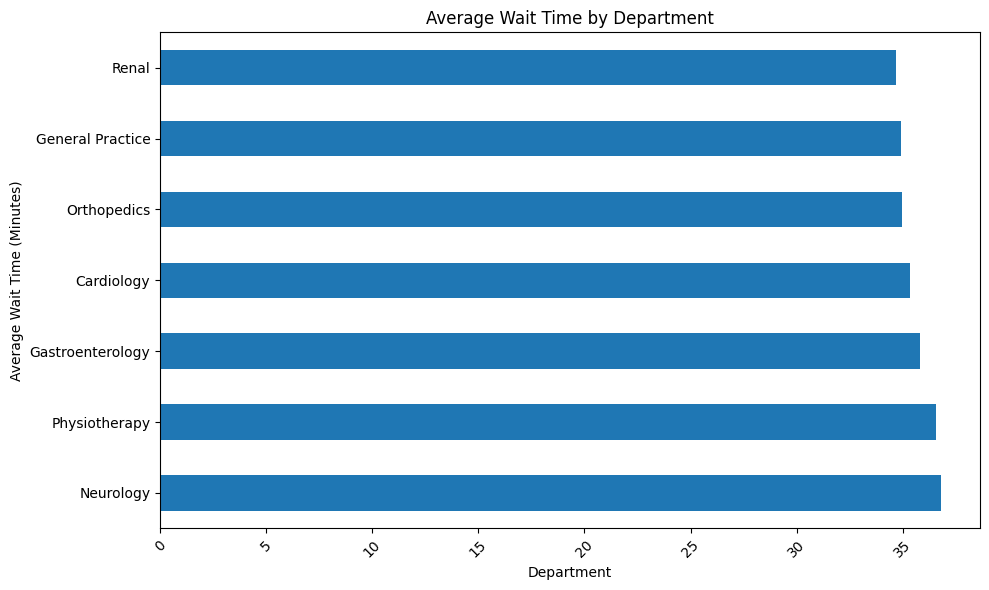

In [10]:
plt.figure(figsize=(10, 6))
dept_wait.plot(kind="barh")
plt.title("Average Wait Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Wait Time (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h3 style = "text-align:left; text-decoration: underline;">
Satisfaction vs Wait Time
</h3>

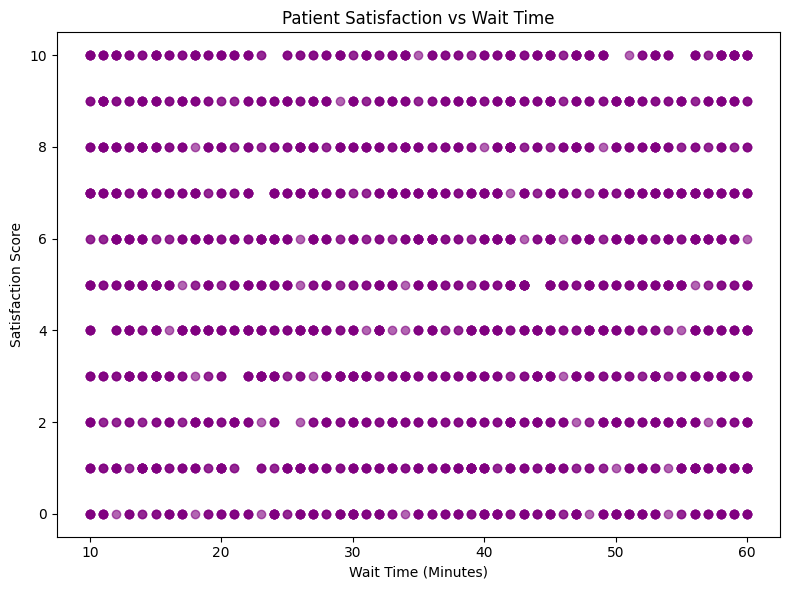

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df["patient_waittime"], df["patient_satisfaction_score"], color = "purple", alpha=0.6)
plt.title("Patient Satisfaction vs Wait Time")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()

<h3 style = "text-alig:left; text-decoration: underline;">
Peak Admission Hours
</h3>

In [12]:
#Convert time column properly
df["patient_admission_time"] = pd.to_datetime(
    df["patient_admission_time"],
    format="%I:%M:%S %p"
)
#Extract hour
df["admission_hour"] = df["patient_admission_time"].dt.hour
hourly_visits = (
    df.groupby("admission_hour")
    .size()
)
print("\nHourly Patient Visits:")
hourly_visits


Hourly Patient Visits:


admission_hour
0     406
1     372
2     376
3     385
4     384
5     393
6     375
7     415
8     386
9     388
10    349
11    403
12    366
13    410
14    368
15    394
16    378
17    359
18    370
19    383
20    372
21    376
22    372
23    436
dtype: int64

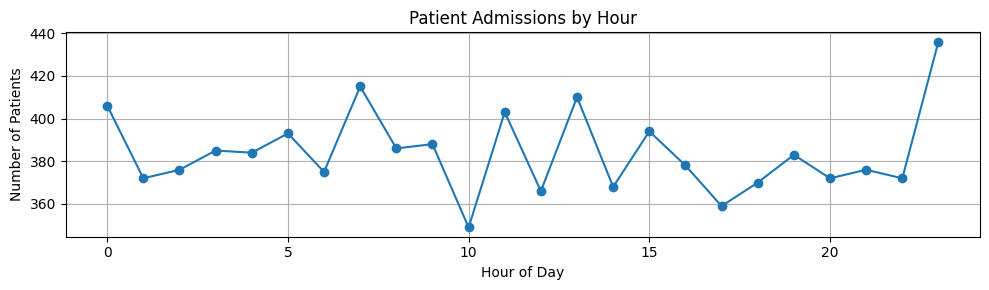

In [13]:
plt.figure(figsize=(10, 3))
ax = hourly_visits.plot(kind="line", marker="o")
plt.title("Patient Admissions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.tight_layout()
plt.show()

<h3 style = "text-align:left; text-decoration: underline;">
Patient Satisfaction Distribution
</h3>

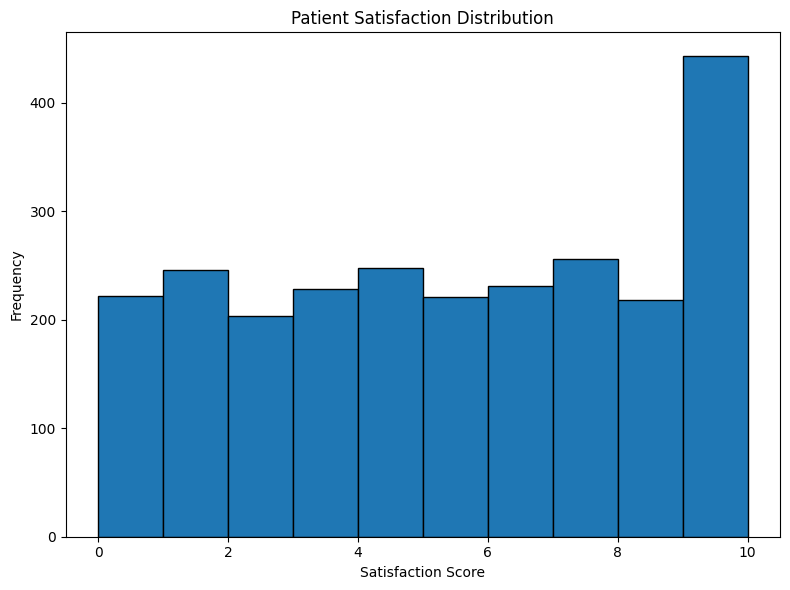

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(df["patient_satisfaction_score"], edgecolor = "black")
plt.title("Patient Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<h3 style = "text-align:left; text-decoration: underline;">
Wait Time Distribution
</h3>

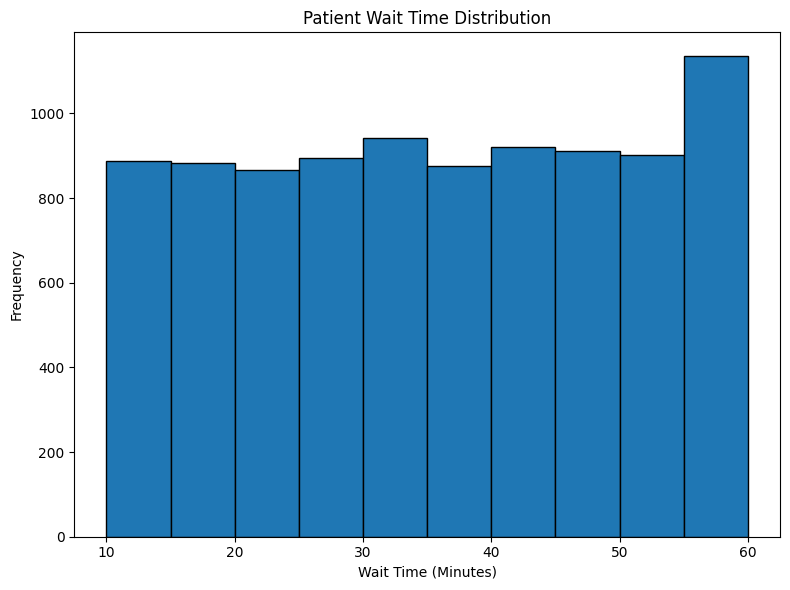

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(df["patient_waittime"], edgecolor = "black")
plt.title("Patient Wait Time Distribution")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()